In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger le fichier nettoyé
df = pd.read_parquet("../data/processed/hopitaux_clean.parquet")
print(df.shape)

(21726, 11)


In [3]:
# Taux moyen de tx_prev_SC par région sur toute la période
df_region = df.groupby("reg")["tx_prev_SC"].mean().sort_values(ascending=False)
print(df_region)

reg
11    4.679347
2     4.538187
93    4.038160
3     3.309374
1     3.243314
32    3.149689
44    3.078767
27    2.894094
84    2.871415
76    2.683556
24    2.621379
4     2.383940
94    2.080494
28    1.925019
75    1.905040
52    1.468672
53    1.315746
6     1.108203
Name: tx_prev_SC, dtype: float64


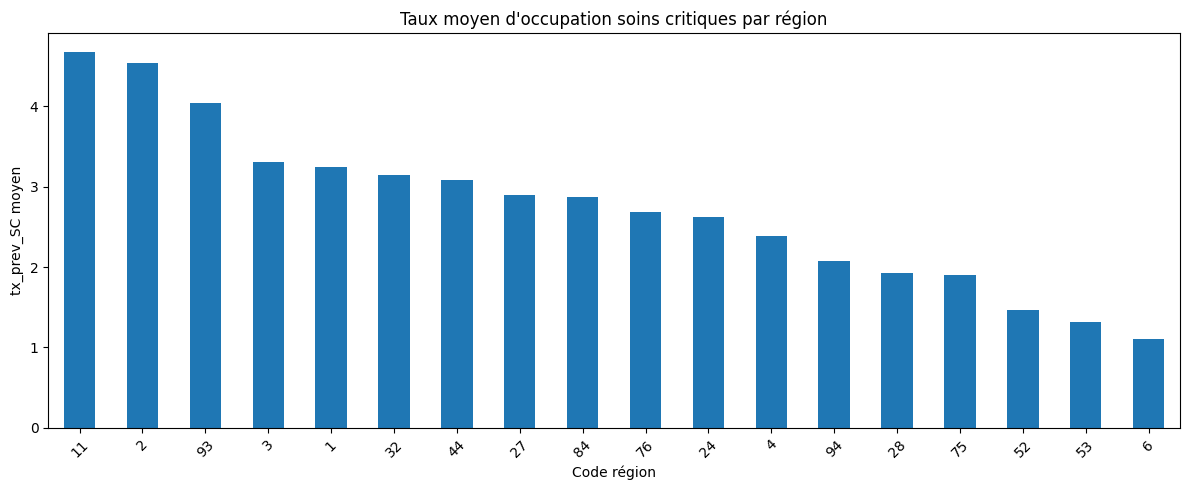

In [4]:
df_region.plot(kind="bar", figsize=(12, 5), title="Taux moyen d'occupation soins critiques par région")
plt.xlabel("Code région")
plt.ylabel("tx_prev_SC moyen")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

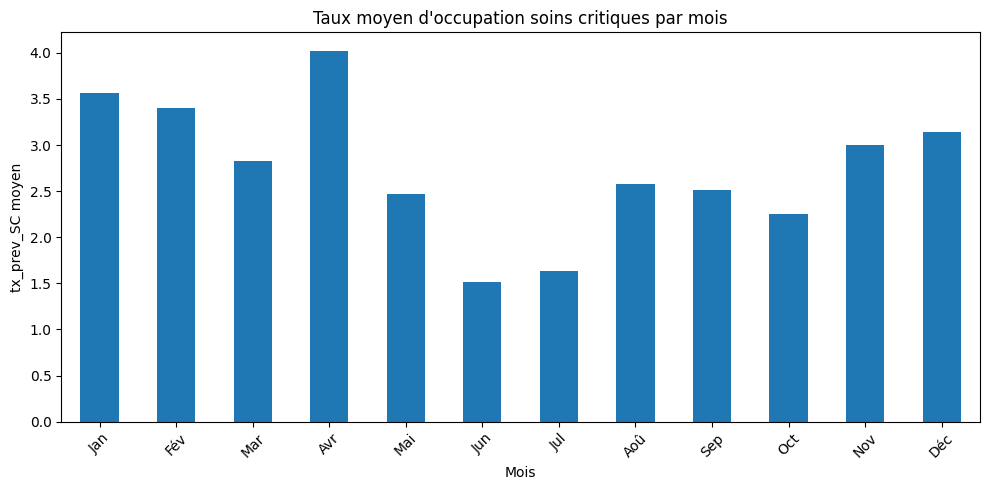

In [5]:
# Taux moyen par mois (tous régions confondues)
df_mois = df.groupby("mois")["tx_prev_SC"].mean()

df_mois.plot(kind="bar", figsize=(10, 5), title="Taux moyen d'occupation soins critiques par mois")
plt.xlabel("Mois")
plt.ylabel("tx_prev_SC moyen")
plt.xticks(ticks=range(12), labels=["Jan", "Fév", "Mar", "Avr", "Mai", "Jun", "Jul", "Aoû", "Sep", "Oct", "Nov", "Déc"], rotation=45)
plt.tight_layout()
plt.show()

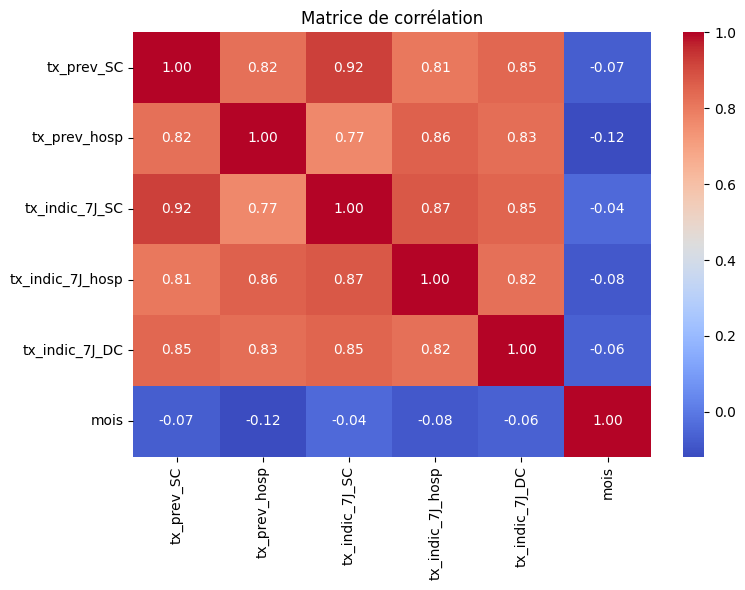

In [6]:
import seaborn as sns

# Matrice de corrélation
corr = df[["tx_prev_SC", "tx_prev_hosp", "tx_indic_7J_SC", "tx_indic_7J_hosp", "tx_indic_7J_DC", "mois"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()